In [128]:
import pandas as pd

In [129]:
from pathlib import Path

json_path = Path("judges_scores.json")
if not json_path.exists():
    json_path = Path("evals/e2e/judges_scores.json")

answers= pd.read_json(json_path)

json_path = Path("ceo_answers_best5.json")
if not json_path.exists():
    json_path = Path("evals/e2e/ceo_answers_best5.json")

data = pd.read_json(json_path)

In [130]:
answers = answers.drop(columns=['response'])

In [131]:
data['tweak'] = data['variant'].apply(lambda x: x.get('tweak'))
data = data.drop(columns=['schema_version','recorded_at'])
data['query'] = data['task'].apply(lambda x: x.get('query'))
data['total_ms'] = data['metrics'].apply(lambda x: x.get('total_ms'))
data['effort'] = data['variant'].apply(lambda x: x.get('effort'))

In [132]:
df = pd.merge(answers, data, left_on='run_id', right_on='run_id', how='left')

In [133]:
df['tool_call_score'] = df['scores'].apply(lambda x: x.get('tool_call_score'))
df['trajectory_score'] = df['scores'].apply(lambda x: x.get('trajectory_score'))
df['final_answer_score'] = df['scores'].apply(lambda x: x.get('final_answer_score'))
df['constraint_adherence_score'] = df['scores'].apply(lambda x: x.get('constraint_adherence_score'))
df['groundedness_score'] = df['scores'].apply(lambda x: x.get('groundedness_score'))
df['hallucination_score'] = df['scores'].apply(lambda x: x.get('hallucination_score'))
df['overall_score'] = df['scores'].apply(lambda x: x.get('overall_score'))
df['tokens'] = df['metrics'].apply(lambda x: x.get('tokens'))
df['total_tokens'] = df['tokens'].apply(lambda x: x.get('total_tokens') if isinstance(x, dict) else None)

In [134]:
df = df.drop(columns=['scores','query_x','query_y','task','variant','metrics','subagent_prompts','subagent_results','ceo_trace','response','reasoning','weaknesses','strengths','tokens'])

In [135]:
# Keep a single final record per run_id: average the judges' scores
score_cols = ['tool_call_score', 'trajectory_score', 'final_answer_score',
              'constraint_adherence_score', 'groundedness_score',
              'hallucination_score', 'overall_score']
agg = {c: 'first' for c in df.columns if c not in score_cols}
agg.update({c: 'mean' for c in score_cols})
df = df.groupby('run_id', as_index=False).agg(agg)
df.sort_values(by='task_id', ascending=True, inplace=True)

In [136]:
df

,judge_number,run_id,task_id,error,tweak,total_ms,effort,total_tokens,tool_call_score,trajectory_score,final_answer_score,constraint_adherence_score,groundedness_score,hallucination_score,overall_score
3,1,1d40e0a8e2c54e879a800b50e77228f5,CEO_008,NaN,cot_n_shot,56099.12,flash,11691.0,9.666667,8.833333,8.066667,10.000000,7.833333,7.666667,8.536667
22,1,eb10bb714762466490f69dfa8ad9293c,CEO_008,NaN,Verification-first,47277.51,flash,9883.0,9.833333,9.100000,8.600000,10.000000,9.000000,9.000000,9.223333
18,1,b69adf9480b34358abb8db093f4d05d6,CEO_008,NaN,reflection,62010.77,flash,10571.0,9.833333,9.166667,8.333333,10.000000,7.000000,7.333333,8.583333
8,1,5e49fcdc09484eae8cf84fb4ccf10b3e,CEO_008,NaN,explicit_planning,81275.18,flash,11961.0,9.666667,9.166667,8.400000,10.000000,7.666667,8.000000,8.813333
17,1,b2678c619d3e40e0a820ba203c866541,CEO_008,NaN,normal,61804.42,flash,10845.0,9.500000,9.000000,8.666667,10.000000,7.500000,7.833333,8.750000
10,1,660ecf740649487faa4303e2f5e35c7c,CEO_008,Judge response did not contain parseable scores,tight_budget,55971.11,flash,10323.0,9.500000,8.250000,8.000000,10.000000,5.750000,6.500000,7.825000
26,1,f380fa8f9f1b4ec8b10f56a7e3fa3cdd,CEO_016,NaN,Verification-first,28245.88,mid,18972.0,8.333333,8.000000,8.166667,9.666667,7.500000,7.666667,8.196667
2,1,1774ed3969094479a8e49882a844adfb,CEO_016,NaN,explicit_planning,96546.19,mid,19854.0,9.066667,8.700000,8.700000,9.500000,8.566667,8.933333,8.906667
21,1,d4c4fefb76ee4d5b867bd154bcb9c7ee,CEO_016,NaN,tight_budget,10422.43,mid,9402.0,8.333333,7.666667,7.333333,9.666667,5.500000,6.166667,7.240000
11,1,76a2be871b894590837de295474e40b2,CEO_016,NaN,normal,43495.17,mid,14935.0,8.333333,8.100000,7.900000,9.566667,7.266667,7.600000,8.130000


In [137]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

# Average judge scores per tweak and per effort mode
score_summary = (
    df.groupby("tweak", dropna=False)[score_cols]
    .mean()
    .round(2)
    .sort_values("overall_score", ascending=False)
)
mode_summary = (
    df.groupby("effort", dropna=False)[score_cols]
    .mean()
    .round(2)
    .sort_values("overall_score", ascending=False)
)

display(score_summary)
display(mode_summary)

# Long-form dataframe for plotting
plot_df = df.melt(
    id_vars=["tweak", "effort", "task_id", "total_ms", "total_tokens"],
    value_vars=score_cols,
    var_name="metric",
    value_name="score",
)

,tool_call_score,trajectory_score,final_answer_score,constraint_adherence_score,groundedness_score,hallucination_score,overall_score
tweak,,,,,,,
normal,8.92,8.55,8.28,9.78,7.38,7.72,8.44
explicit_planning,8.27,7.69,7.58,8.90,6.91,7.39,7.76
cot_n_shot,7.91,7.30,7.55,8.59,6.67,6.93,7.44
reflection,8.19,7.17,7.04,8.90,6.05,6.50,7.23
tight_budget,6.23,5.64,5.89,7.10,4.78,7.43,5.77
Verification-first,5.57,5.19,5.10,6.27,5.57,8.93,5.47


,tool_call_score,trajectory_score,final_answer_score,constraint_adherence_score,groundedness_score,hallucination_score,overall_score
effort,,,,,,,
flash,9.67,8.92,8.34,10.00,7.46,7.72,8.62
mid,6.70,6.12,6.30,7.54,5.71,7.38,6.36


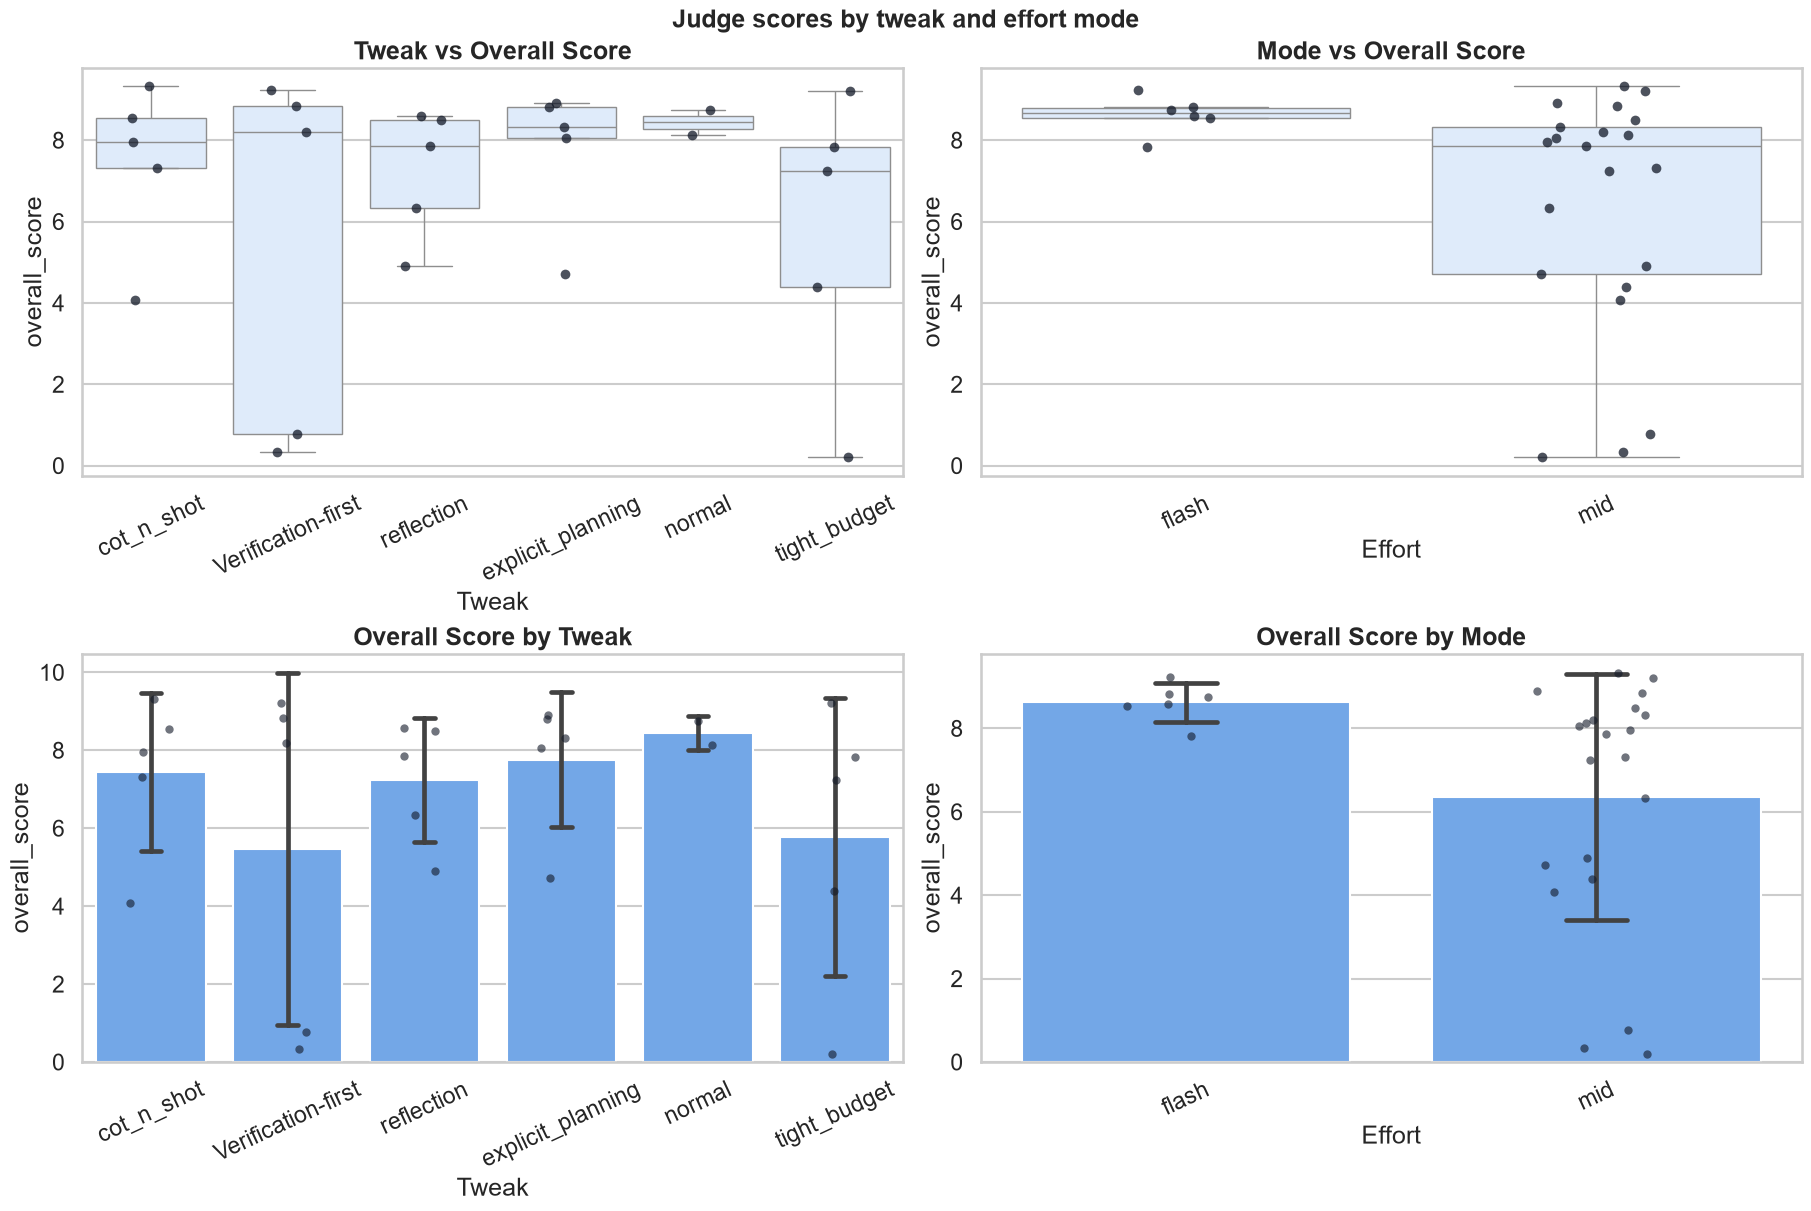

In [141]:
# 2x2 collage: overall score by tweak/mode (top: boxplots, bottom: bars with error bars)
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

# Row 0: overall score by tweak and by effort mode
for ax, (x_col, title) in zip(axes[0], [("tweak", "Tweak vs Overall Score"), ("effort", "Mode vs Overall Score")]):
    sns.boxplot(data=df, x=x_col, y="overall_score", ax=ax, color="#dbeafe", showfliers=False)
    sns.stripplot(data=df, x=x_col, y="overall_score", ax=ax, color="#111827", alpha=0.75, jitter=0.15, size=7)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(x_col.capitalize())
    ax.tick_params(axis="x", rotation=25)

# Row 1: overall score by tweak and by mode (mean +/- std)
for ax, (x_col, title) in zip(axes[1], [("tweak", "Overall Score by Tweak"), ("effort", "Overall Score by Mode")]):
    sns.barplot(data=df, x=x_col, y="overall_score", ax=ax, color="#60a5fa", errorbar="sd", capsize=0.15)
    sns.stripplot(data=df, x=x_col, y="overall_score", ax=ax, color="#111827", alpha=0.6, jitter=0.15, size=6)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(x_col.capitalize())
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Judge scores by tweak and effort mode", fontsize=18, fontweight="bold")
output_path = Path("/home/electron/Documents/GitHub/Co_Founder/docs/answera_scores_eda.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, bbox_inches="tight", dpi=200)
plt.show()

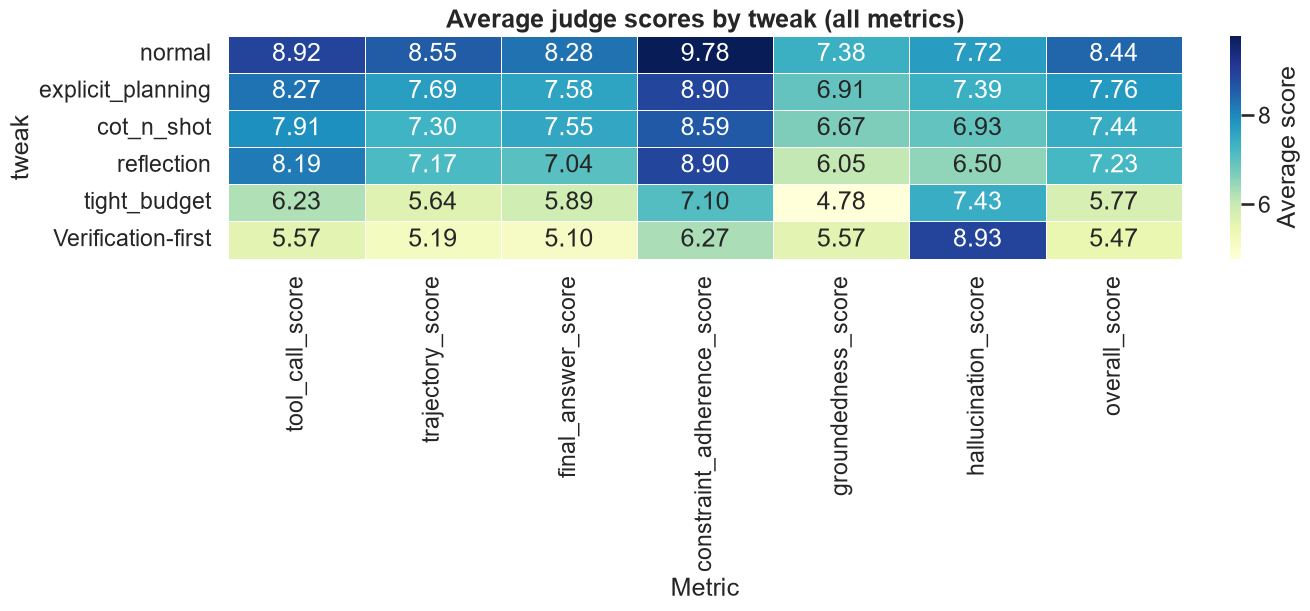

In [139]:
# Heatmap: average of every judge metric by tweak
fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
sns.heatmap(
    score_summary,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Average score"},
)
ax.set_title("Average judge scores by tweak (all metrics)", fontweight="bold")
ax.set_xlabel("Metric")
plt.show()

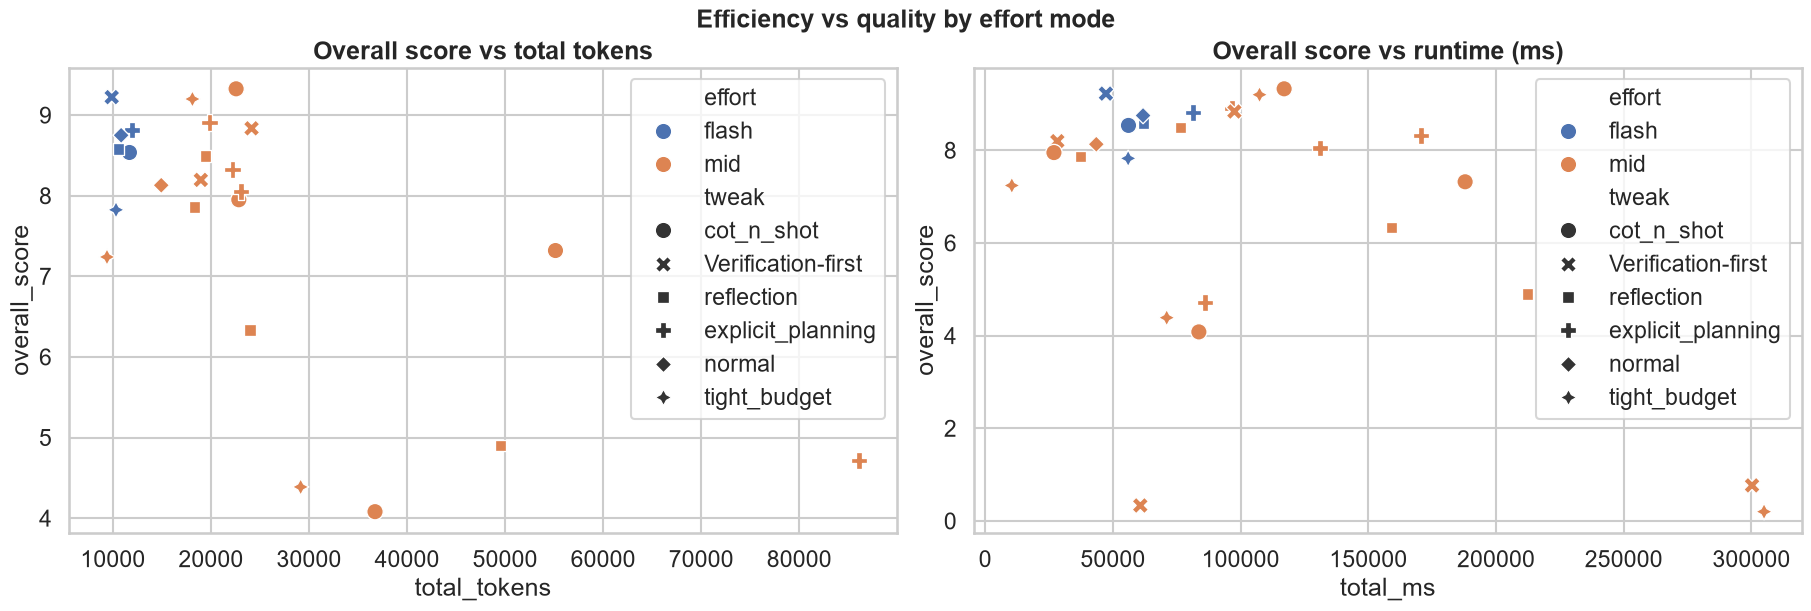

In [140]:
# Efficiency vs quality: overall score against tokens and runtime, colored by mode
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

sns.scatterplot(data=df, x="total_tokens", y="overall_score", hue="effort", style="tweak", s=140, ax=axes[0])
axes[0].set_title("Overall score vs total tokens", fontweight="bold")

sns.scatterplot(data=df, x="total_ms", y="overall_score", hue="effort", style="tweak", s=140, ax=axes[1])
axes[1].set_title("Overall score vs runtime (ms)", fontweight="bold")

fig.suptitle("Efficiency vs quality by effort mode", fontsize=18, fontweight="bold")
plt.show()